# Классификация текста 
## Ссылки

https://www.youtube.com/watch?v=AwdawjHJstU - Классификация текста | Обработка естественного языка</br>
https://www.youtube.com/watch?v=55Iyei3bkKk&list=PLtPJ9lKvJ4ohZpMV9Ml-DPtMSXPFNl6Sz</br>

https://www.youtube.com/watch?v=-2O0ODmnw1o - NLP cookbook: анализируем тексты на Python с минимальными знаниями о машинном обучении

# 0. Импорты

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords
import string
import re
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


# 1. Загрузка датасета

In [2]:
df = pd.read_json("data/data.txt", lines=True)
df

,text,tags,schema_name,table_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876


In [3]:
final_df = df.copy()

# Мультиклассовая классификация на основе имён таблиц

In [4]:
final_df['full_table_name'] = final_df['schema_name'] + '.' + final_df['table_name']
# final_df['class_name'] =  final_df['tags'].apply(lambda x: '/'.join(x))
codes, class_unique_names = pd.factorize(final_df['full_table_name']) # для Multiclass классификации на основе имени таблицы
# codes - идентификаторы, unique_names - названия классов
final_df['class_id'] = codes
# также сделать дял multilable classification. Если нет тегов, то брать имя таблицы
final_df

,text,tags,schema_name,table_name,full_table_name,class_id
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20


# Анализ датасета
## Распределение данных по классам

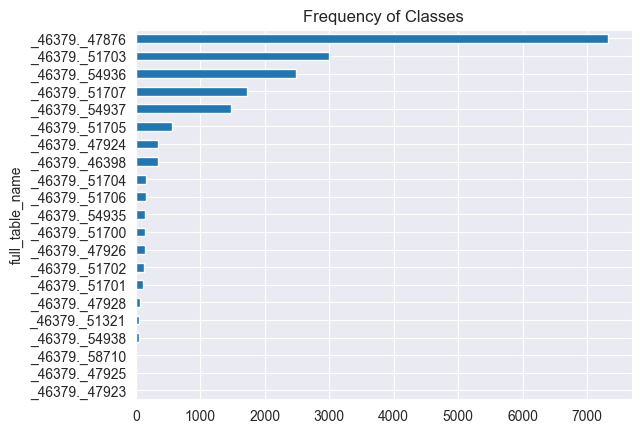

In [5]:
# узнаем кол-во примеров в каждом классе
final_df["full_table_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [6]:
final_df["full_table_name"].value_counts(ascending=True)

full_table_name
_46379._47923       1
_46379._47925       1
_46379._58710       6
_46379._54938      46
_46379._51321      50
_46379._47928      64
_46379._51701     108
_46379._51702     133
_46379._47926     144
_46379._51700     146
_46379._54935     148
_46379._51706     156
_46379._51704     164
_46379._46398     342
_46379._47924     343
_46379._51705     558
_46379._54937    1483
_46379._51707    1727
_46379._54936    2485
_46379._51703    2992
_46379._47876    7327
Name: count, dtype: int64

## Распределение кол-ва токенов в классах

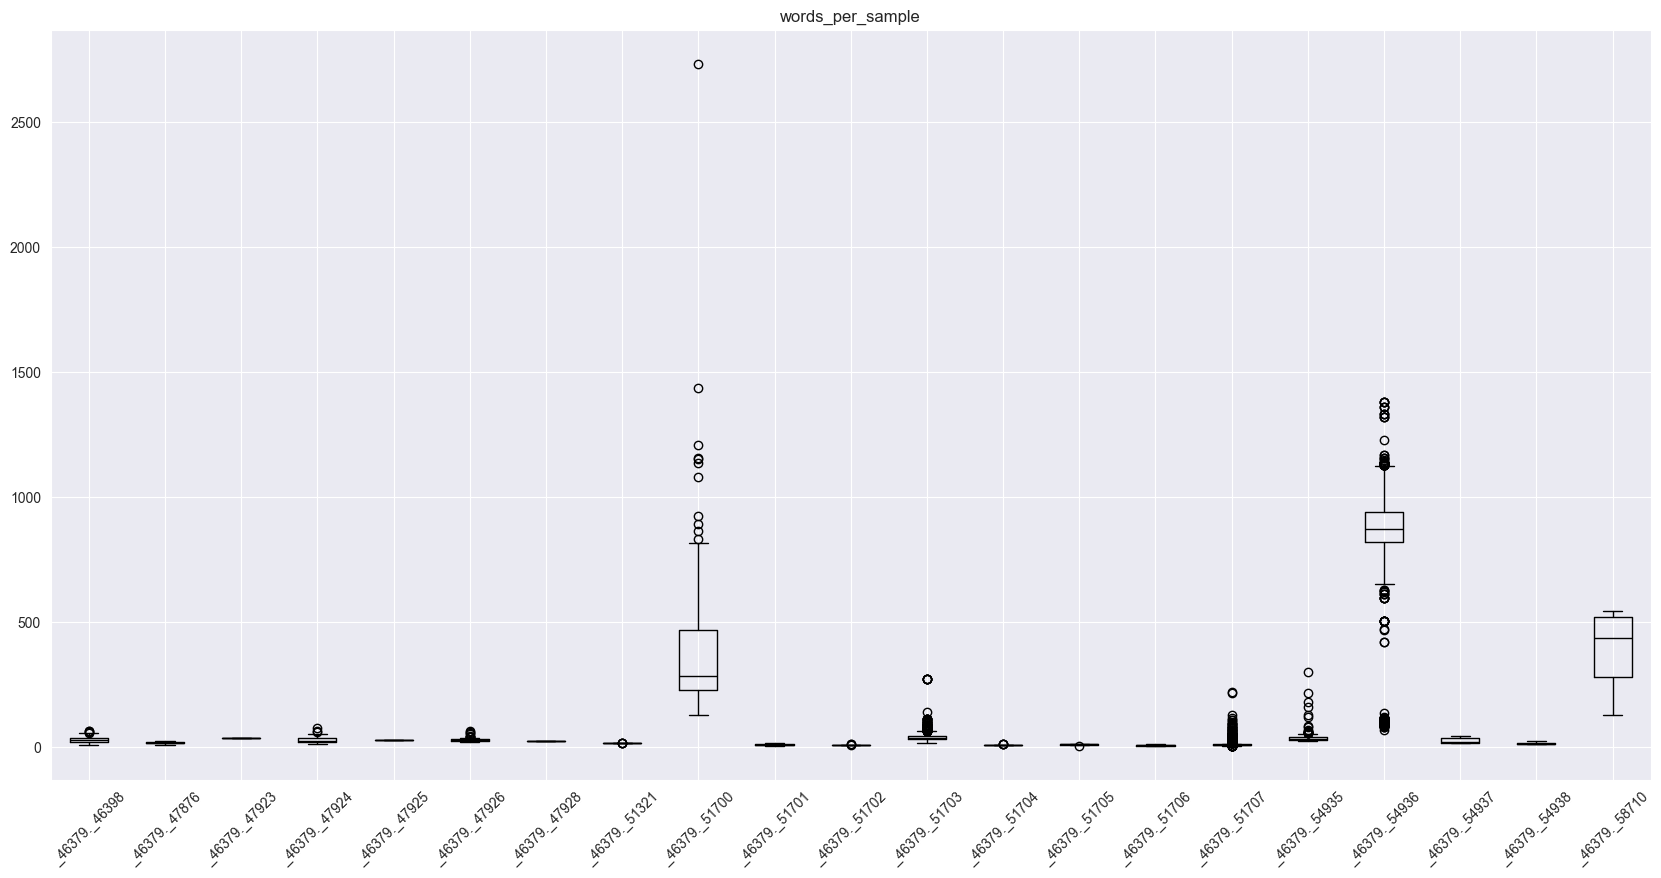

In [7]:
# кол-во слов в каждом классе
final_df["words_per_sample"] = final_df["text"].str.split().apply(len)
final_df.boxplot("words_per_sample", by="full_table_name", grid=True,
showfliers=True, color="black", figsize=(20, 10), rot=45)
plt.suptitle("")
plt.xlabel("")
plt.show()


# Формирование датафрейма. Предобработка данных. Получение эмбедингов.Общие стандартные шаги для начала работы

Итоговые рекомендации:
Прекратите удалять стоп-words и, возможно, прекратите приводить к нижнему регистру. Просто проведите базовую очистку: удалите лишние пробелы, спецсимволы, HTML-теги, если они есть, и т.д.

Никакой дополнительной токенизации не нужно. Просто передавайте строку в model.encode(). Доверяйте встроенному пайплайну SentenceTransformer. Он отлично спроектирован и сам выполнит всю необходимую низкоуровневую работу. Ваша задача — подать на вход качественный, связный текст

In [8]:
# Загрузка модели Sentence-BERT (выбираем multilingual версию)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

In [9]:
# Загрузка стоп-слов (один раз при старте)
# nltk.download('stopwords')
# stop_words = set(stopwords.words('russian')) # Загрузка стоп-слов (один раз при старте)

In [10]:
# Функция для очистки текста
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Удаление URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    # Удаление цифр и специальных символов
    text = re.sub(r'\d+', ' ', text)
    # Удаление пунктуации
    # text = text.translate(str.maketrans('', '', string.punctuation))
    translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    text = text.translate(translator)
    # Приведение к нижнему регистру (не всегда обязательно, возможно ухудшит качество)
    text = text.lower()
    # Удаление стоп-слов (не всегда  обязательно, возможно ухудшит качество)
    # stop_words = set(stopwords.words('russian'))
    words = text.split()
    # words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

In [11]:
# Функция для получения имени сервиса. Именем сервиса является номер на 2-ой позиции в списке тегов
def get_service_name(list_of_tags):
    # если недостаточное кол-во тегов -> нет сервиса -> возвращаем пустую строку
    if len(list_of_tags) < 2:
        return ''
    service_name = list_of_tags[1]
    return service_name

In [12]:
# Функция для получения осмысленного имени таблицы. Именем таблицы является последний номер в списке тегов
def get_table_info_name(tags, table_name):

    # если недостаточное кол-во тегов -> нет сервиса -> возвращаем пустую строку
    if len(tags) == 0:
        # return ''
        return table_name
    table_info_name = tags[-1] # получаем последнюю строку
    return table_info_name

In [13]:
# Функция для обработки чанка с очисткой текста
def process_chunk(chunk):
    """Генерирует эмбеддинги для чанка с предварительной очисткой"""
    # Очищаем тексты
    cleaned_texts = chunk['text'].apply(clean_text).tolist()
    # получаем имена сервисов
    service_names = chunk['tags'].apply(get_service_name).tolist()
    # получаем осмысленное имя таблицы
    table_info_name = chunk.apply(lambda row: get_table_info_name(row['tags'], row['full_table_name']), axis=1).tolist()
    # chunk.apply(lambda row: get_table_info_name(row))
    # table_info_name = chunk.apply(get_table_info_name).tolist()
    # Генерируем эмбеддинги для всех текстов в чанке
    embeddings = model.encode(cleaned_texts, 
                            show_progress_bar=False,
                            convert_to_numpy=True)
    
    # Добавляем результаты в чанк
    chunk['cleaned_text'] = cleaned_texts
    chunk['embeddings'] = list(embeddings)
    chunk['service_name'] = service_names
    chunk['table_info_name'] = table_info_name
    return chunk

In [14]:
final_df

,text,tags,schema_name,table_name,full_table_name,class_id,words_per_sample
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0,39
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,130
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,372
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,252
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,504
...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,13
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,17


In [15]:
# Размер чанка (подбирайте под ваши ресурсы)
CHUNK_SIZE = 1000  
# Инициализация прогресс-бара
pbar = tqdm(total=len(final_df), desc="Обработка датафрейма")
# Обработка по чанкам
results = []
for i in range(0, len(final_df), CHUNK_SIZE):
    chunk = final_df.iloc[i:i + CHUNK_SIZE].copy()
    processed_chunk = process_chunk(chunk)
    results.append(processed_chunk)
    pbar.update(len(chunk))
pbar.close()

# Сборка финального датафрейма
final_df = pd.concat(results, ignore_index=True)

Обработка датафрейма: 100%|██████████| 18424/18424 [00:13<00:00, 1358.87it/s]


In [16]:
final_df

,text,tags,schema_name,table_name,full_table_name,class_id,words_per_sample,cleaned_text,embeddings,service_name,table_info_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0,39,часть территории национального парка лосиный о...,"[0.3547967, 0.16676068, 0.07977914, -0.0005325...",440 Особо охраняемые природные территории,Границы ООПТ
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,130,часть территории национального парка лосиный о...,"[0.22239774, 0.15734524, 0.013664918, -0.04089...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,372,часть территории национального парка лосиный о...,"[0.28809375, 0.14398257, 0.04981663, -0.006072...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,252,часть территории национального парка лосиный о...,"[0.28809375, 0.14398257, 0.04981663, -0.006072...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,504,часть территории национального парка лосиный о...,"[0.36440247, 0.12335314, 0.059311002, -0.05470...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
...,...,...,...,...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,13,jpg photo зелао уч комплексный заказник зелено...,"[0.15561336, 0.32526222, 0.0925827, 0.00283530...",440 Особо охраняемые природные территории,Фотофиксация
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22,jpg photo юзао и юао пип битцевский лес участо...,"[0.0332909, 0.2387227, 0.2250042, 0.11981269, ...",440 Особо охраняемые природные территории,Фотофиксация
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22,jpg photo юзао и юао пип битцевский лес участо...,"[0.0332909, 0.2387227, 0.2250042, 0.11981269, ...",440 Особо охраняемые природные территории,Фотофиксация
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,17,jpg photo зелао уч комплексный заказник зелено...,"[0.15561336, 0.32526222, 0.0925827, 0.00283530...",440 Особо охраняемые природные территории,Фотофиксация


# Класификация по таблицам

In [17]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [18]:
final_df['class_id'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])

In [19]:
final_df['class_id']

0         0
1         1
2         1
3         1
4         1
         ..
18419    20
18420    20
18421    20
18422    20
18423    20
Name: class_id, Length: 18424, dtype: int64

In [20]:
# Проблема в том, что final_df['embeddings'] содержит массивы или списки, а не плоские числовые значения. Вот как это исправить:
X = final_df['embeddings']
# Преобразуем список/серию эмбеддингов в 2D numpy array
X = np.vstack(X.values)  # или np.array(X.tolist())
y = final_df['class_id'].values


In [21]:
# Разделение на train/test. Не работает т.к. в некоторых классах могут быть только один сэмпл
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
from sklearn.utils import shuffle
def manual_stratified_split(X, y, test_size=0.2, random_state=42):
    """
    Ручное стратифицированное разделение для данных с редкими классами
    Учитывает, что в некоторых классах может быть один сэмпл
    """
    
    unique_classes = np.unique(y)
    X_train, X_test, y_train, y_test = [], [], [], []
    
    for cls in unique_classes:
        # Выбираем samples текущего класса
        mask = y == cls
        X_cls = X[mask]
        y_cls = y[mask]
        
        n_samples = len(X_cls)
        
        if n_samples == 1:
            # Если только 1 sample - всегда в train
            X_train.append(X_cls)
            y_train.append(y_cls)
            # и в тест тоже
            X_test.append(X_cls)
            y_test.append(y_cls)
        else:
            # Разделяем класс
            n_test = max(1, int(n_samples * test_size))  # минимум 1 в test
            n_train = n_samples - n_test
            
            # Перемешиваем
            X_cls, y_cls = shuffle(X_cls, y_cls, random_state=random_state)
            
            X_train.append(X_cls[:n_train])
            X_test.append(X_cls[n_train:n_train + n_test])
            y_train.append(y_cls[:n_train])
            y_test.append(y_cls[n_train:n_train + n_test])
    
    # Объединяем результаты
    X_train = np.vstack(X_train) if hasattr(X[0], 'shape') else np.concatenate(X_train)
    X_test = np.vstack(X_test) if hasattr(X[0], 'shape') else np.concatenate(X_test)
    y_train = np.concatenate(y_train)
    y_test = np.concatenate(y_test)
    
    return X_train, X_test, y_train, y_test

# Использование
X_train, X_test, y_train, y_test = manual_stratified_split(X, y, test_size=0.2)

In [23]:
# Обучение классификатора
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train, y_train)
    
# Предсказание и оценка
y_pred = classifier.predict(X_test)
    
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

Accuracy: 0.9980967917346384

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00         1
           1       1.00      0.00      0.00         1
           2       1.00      0.00      0.00         1
           3       1.00      1.00      1.00        12
           4       1.00      0.97      0.98        29
           5       1.00      1.00      1.00       497
           6       1.00      1.00      1.00       296
           7       0.90      1.00      0.95         9
           8       1.00      1.00      1.00        32
           9       1.00      0.95      0.98        21
          10       0.97      1.00      0.98        29
          11       1.00      1.00      1.00        26
          12       1.00      1.00      1.00       598
          13       1.00      1.00      1.00        31
          14       1.00      1.00      1.00       111
          15       1.00      1.00      1.00        28
          16       1.00     

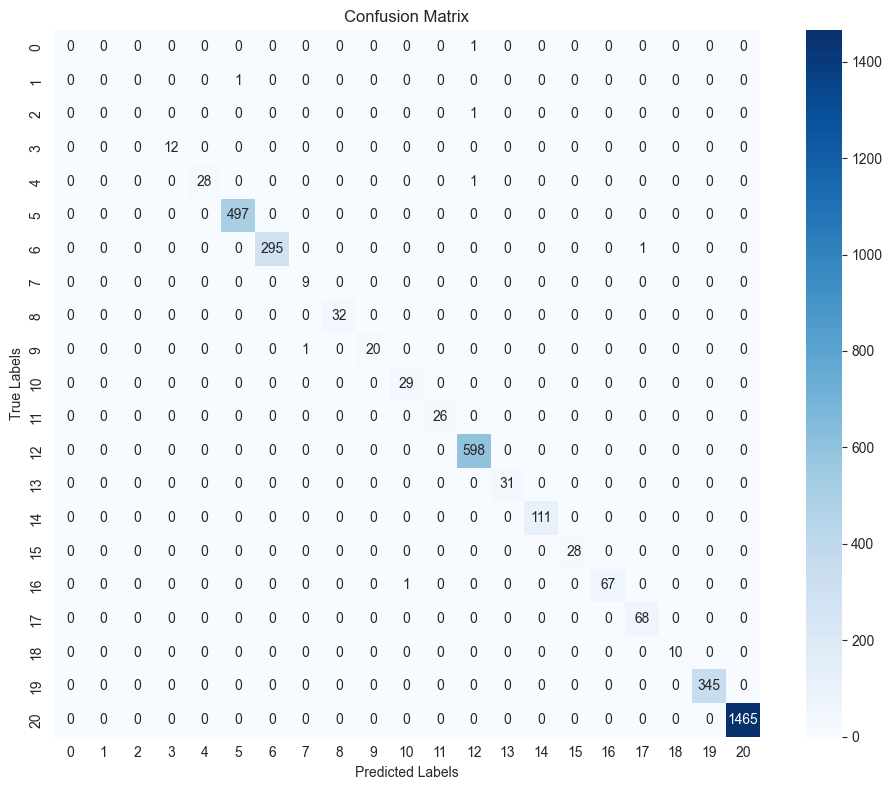

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(10, 8))
# Вычисляем confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=True,
            # xticklabels=class_unique_names,
            # yticklabels=class_unique_names,
            square=True)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

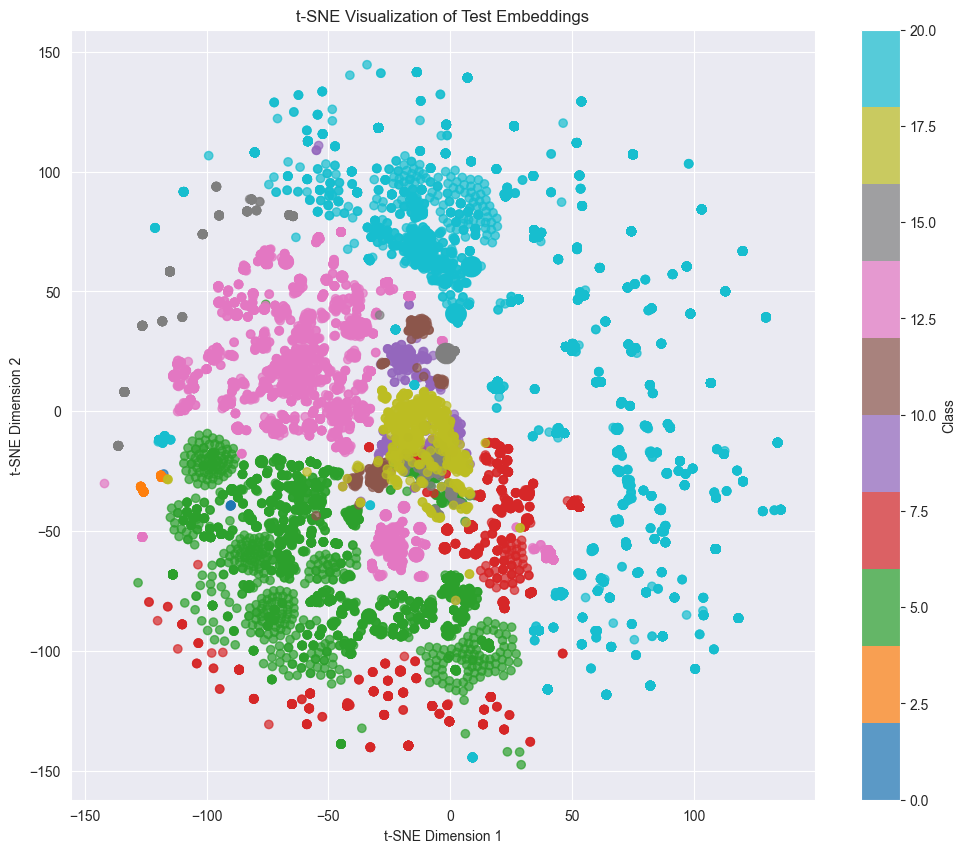

In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Уменьшаем размерность для визуализации
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Class')
plt.title('t-SNE Visualization of Test Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [26]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

In [27]:
import plotly.express as px

# Подготовка данных для визуализации
df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'classes': final_df['class_id'],
    'full_table_name': final_df['full_table_name']
})
# Интерактивная визуализация
fig = px.scatter(
    df,
    x='x',
    y='y',
    color='classes',
    hover_data=['full_table_name'],
    title='t-SNE Visualization of Test Embeddings',
    width=1000,
    height=600
)
fig.update_traces(marker=dict(size=12, opacity=0.7))
fig.show()

# DummyClassifier - проверяем дейтсвительно ли полученная модеоь справляется лучше, чем случайный выбор по выбранной стратегии

In [28]:
from sklearn.dummy import DummyClassifier
# Создаем несколько стратегий dummy classifier
strategies = ['stratified', 'most_frequent', 'prior', 'uniform', 'constant']

# strategy = 'most_frequent'
results = []
for strategy in strategies:
    if strategy == 'constant':
        # Для constant стратегии нужно указать constant value
        dummy = DummyClassifier(strategy=strategy, constant=y_train[0])
    else:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        
    # Обучаем и предсказываем
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
        
    # Вычисляем accuracy
    accuracy = accuracy_score(y_test, y_pred_dummy)
        
    results.append({
        'strategy': strategy,
        'accuracy': accuracy,
        'predictions': y_pred_dummy
        })
        
    print(f"Dummy classifier {strategy}: Accuracy = {accuracy:.4f}")

# Сравниваем с вашей моделью
real_model_accuracy = accuracy_score(y_test, y_pred)
print(f"Real classifier: Accuracy = {real_model_accuracy:.4f}")

Dummy classifier stratified: Accuracy = 0.2200
Dummy classifier most_frequent: Accuracy = 0.3983
Dummy classifier prior: Accuracy = 0.3983
Dummy classifier uniform: Accuracy = 0.0484
Dummy classifier constant: Accuracy = 0.0003
Real classifier: Accuracy = 0.9981


In [29]:
# предсказание
test_text = '1 1 1 Часть территории национального парка \"Лосиный остров\", расположенная в границах города Москвы ППМ № 769-ПП от 11.04.2025 ИК Зона охраны объектов культурного наследия (памятников истории и культуры) народов Российской Федерации 3.1. Коммунальное обслуживание. 3.9. Обеспечение научной деятельности. 5.2. Природно-познавательный туризм. 9.0. Деятельность по особой охране и изучению природы. 9.1. Охрана природных территорий. 9.3. Историко-культурная деятельность. 12.0. Земельные участки (территории) общего пользования - выполнение инженерно-геологических изысканий; - строительство и реконструкция объектов, сооружений и инженерно-технических коммуникаций, связанных с охраной и использованием Национального парка в границах города Москвы, в границах участков размещения объектов капитального строительства; - поддержание в исправном состоянии существующей дорожно-тропиночной сети, сетей наружного освещения, элементов благоустройства; - создание и обустройство зон с информационными площадками Ограничения определяются законодательством Российской Федерации и города Москвы об объектах культурного наследия. 12.032815458365 2323.37880952977 120328.1495391'
cleaned_test_text = clean_text(test_text)
encoded_test_text = model.encode(cleaned_test_text)
# encoded_test_text = np.vstack(encoded_test_text.values)  # или np.array(X.tolist())
test_result = classifier.predict([encoded_test_text])
test_proba = classifier.predict_proba([encoded_test_text])
test_proba

array([[3.73672236e-03, 2.18003637e-01, 3.60661943e-03, 3.59312159e-02,
        1.19473579e-02, 5.24250172e-01, 1.11111475e-04, 1.51032332e-03,
        1.24093461e-04, 2.75780031e-04, 3.39995884e-02, 5.84854658e-04,
        6.90796802e-02, 5.42104170e-04, 9.52830625e-04, 5.71911600e-04,
        5.36895125e-02, 8.23296275e-03, 3.14267739e-02, 9.35965719e-04,
        4.86782117e-04]])

In [30]:
len(class_unique_names)

21

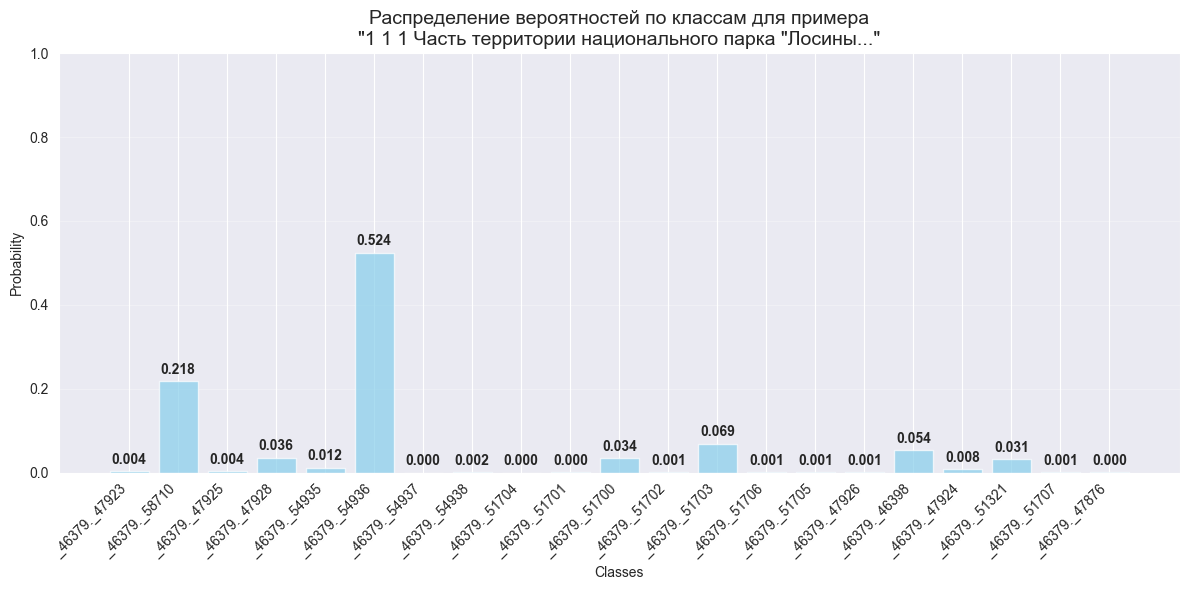

In [31]:
# Создаем bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(class_unique_names)), test_proba[0], color='skyblue', alpha=0.7)

plt.title(f'Распределение вероятностей по классам для примера\n"{test_text[:50]}..."', fontsize=14)
plt.xlabel('Classes')
plt.ylabel('Probability')
plt.xticks(range(len(class_unique_names)), class_unique_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (bar, prob) in enumerate(zip(bars, test_proba[0])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{prob:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('single_sample_proba.png', dpi=300, bbox_inches='tight')
plt.show()

# Применим GridSearchCV для подбора оптимальных параметров

In [32]:
from sklearn.model_selection import GridSearchCV
# Best practice для начала
param_grid = {
    'C': [0.1, 1, 10, 100],
    'class_weight': [None, 'balanced'],
    'solver': ['lbfgs', 'liblinear']
}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)

D:\Artem\Magistrature\1_sem\intellg_systems_and_techno\labs\.venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [33]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая accuracy:", grid_search.best_score_)

# Используем лучшую модель
best_classifier = grid_search.best_estimator_

Лучшие параметры: {'C': 10, 'class_weight': 'balanced', 'solver': 'liblinear'}
Лучшая accuracy: 0.998643929858441


# Альтернативные варианты </br>
1. LinearSVC (линейный SVM) </br>
2. Random Forest <br>
3. Gradient Boosting (XGBoost/LightGBM/CatBoost) </br>
4. MLP (нейронная сеть) </br>
5. Ансамбли </br>

Визуализация сравнения моделей </br>


In [34]:
# pip install xgboost
# from xgboost import XGBClassifier
# from sklearn.svm import LinearSVC
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neural_network import MLPClassifier
# from sklearn.ensemble import VotingClassifier
# from sklearn.model_selection import cross_validate
# from sklearn.model_selection import cross_validate
# from sklearn.model_selection import cross_val_score

In [35]:
# Альтернативные модели
# models = {
#     'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
#     'LinearSVC': LinearSVC(random_state=42),
#     'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'XGBoost': XGBClassifier(use_label_encoder=False, random_state=42)
# }
# # Ансамбль нескольких моделей
# ensemble = VotingClassifier(
#     estimators=[
#         ('logreg', LogisticRegression(max_iter=1000, random_state=42)),
#         ('svm', LinearSVC(random_state=42)),
#         ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
#     ],
#     voting='soft'  # для вероятностей
# )

# Multilable classification по структуре в orbis (тегам). Если нет тегов, то используем имя таблицы

In [36]:
# подготовим датасет
# определим список уникальных тегов
tags = [item for item in final_df['tags']]
unique_tags  = list(set(tag for sublist in tags for tag in sublist))
unique_tags

['Охранные зоны ООПТ',
 'Земельные участки',
 'МКА. Геоданные',
 'Достопримечательности',
 'Почва',
 'Зонирование, Режимы охраны и использования ООПТ (архив)',
 'Кадастр ООПТ',
 'Архив',
 'Гидрология (линейные объекты)',
 'Фотофиксация',
 'Флора и фауна',
 'Территории ООПТ по ППМ',
 'Границы ООПТ (архив)',
 'ООПТ (точки)',
 'Рельеф',
 'Гидрология (площадные объекты)',
 'Зонирование, Режимы охраны и использования ООПТ',
 'Границы ООПТ',
 'Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ',
 'Проверка ООПТ',
 'ООПТ в соответствии с Законом города Москвы № 37 от 06.07.2005',
 'Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ (архив)',
 'Охранные зоны ООПТ (архив)',
 '440 Особо охраняемые природные территории']

In [37]:
empty_tags_df = final_df[final_df['tags'].apply(lambda x: isinstance(x, list) and len(x) == 0)]
unique_table_names_with_empty_tags = empty_tags_df['full_table_name'].unique().tolist()

In [38]:
unique_labels = unique_tags + unique_table_names_with_empty_tags
unique_labels

['Охранные зоны ООПТ',
 'Земельные участки',
 'МКА. Геоданные',
 'Достопримечательности',
 'Почва',
 'Зонирование, Режимы охраны и использования ООПТ (архив)',
 'Кадастр ООПТ',
 'Архив',
 'Гидрология (линейные объекты)',
 'Фотофиксация',
 'Флора и фауна',
 'Территории ООПТ по ППМ',
 'Границы ООПТ (архив)',
 'ООПТ (точки)',
 'Рельеф',
 'Гидрология (площадные объекты)',
 'Зонирование, Режимы охраны и использования ООПТ',
 'Границы ООПТ',
 'Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ',
 'Проверка ООПТ',
 'ООПТ в соответствии с Законом города Москвы № 37 от 06.07.2005',
 'Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ (архив)',
 'Охранные зоны ООПТ (архив)',
 '440 Особо охраняемые природные территории']

In [39]:
label_codes, labels_unique_names = pd.factorize(np.array(unique_labels))
label_codes

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [40]:
labels_codes_maping = dict(zip(labels_unique_names, label_codes))
labels_codes_maping

{np.str_('Охранные зоны ООПТ'): np.int64(0),
 np.str_('Земельные участки'): np.int64(1),
 np.str_('МКА. Геоданные'): np.int64(2),
 np.str_('Достопримечательности'): np.int64(3),
 np.str_('Почва'): np.int64(4),
 np.str_('Зонирование, Режимы охраны и использования ООПТ (архив)'): np.int64(5),
 np.str_('Кадастр ООПТ'): np.int64(6),
 np.str_('Архив'): np.int64(7),
 np.str_('Гидрология (линейные объекты)'): np.int64(8),
 np.str_('Фотофиксация'): np.int64(9),
 np.str_('Флора и фауна'): np.int64(10),
 np.str_('Территории ООПТ по ППМ'): np.int64(11),
 np.str_('Границы ООПТ (архив)'): np.int64(12),
 np.str_('ООПТ (точки)'): np.int64(13),
 np.str_('Рельеф'): np.int64(14),
 np.str_('Гидрология (площадные объекты)'): np.int64(15),
 np.str_('Зонирование, Режимы охраны и использования ООПТ'): np.int64(16),
 np.str_('Границы ООПТ'): np.int64(17),
 np.str_('Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ'): np.int64(18),
 np.str_('П

In [48]:
final_df['multilabel_ids'] = None
final_df

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 1 1 1 Часть территории национального п

In [49]:
for _, row in final_df.iterrows():
    if len(row['tags']) == 0:
        row['multilabel_ids'] = [labels_codes_maping[row['full_table_name']]]
    else:
        label_ids = []
        for tag in row['tags']:
            label_ids.append(labels_codes_maping[tag])
        row['multilabel_ids'] = label_ids
final_df

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 1 1 1 Часть территории национального п

In [56]:
def add_multilabel_ids(row):
    if len(row['tags']) == 0:
        row['multilabel_ids'] = [labels_codes_maping[row['full_table_name']]]
    else:
        label_ids = []
        for tag in row['tags']:
            label_ids.append(labels_codes_maping[tag])
            # print(label_ids)
        row['multilabel_ids'] = label_ids
final_df.apply(lambda row: add_multilabel_ids(row),axis=1)
final_df

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 1 1 1 Часть территории национального п